In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_distances
from sklearn.metrics import pairwise_distances

# Change Working Dir To the Project Working Dir (for Noam)

In [2]:
import ipynbname
# change the dir to the grandparent directory of the current working directory

note_dir = ipynbname.path().parent
grandparent_dir = note_dir.parent.parent
os.chdir(grandparent_dir)
print(os.getcwd())  # Check the cwd has updated

c:\Users\noams\Python Projects\Audio_processing_project


# Classical Clustering

## Naive Clustering

In [3]:
raw_data = pd.read_csv(Path("tcav_per_sample_with_acc.csv"))

In [4]:
raw_data

,path,concept_name,layer_name,positive_percentage,magnitude,cav_acc,true_label,predicted_label,predicted_probability
0,RAVDESS\original_data\Actor_23\03-01-02-02-02-...,long_constant_thick,module3.blocks.0.conv2,0.0,-0.479544,0.956522,calm,calm,0.999167
1,RAVDESS\original_data\Actor_23\03-01-02-02-02-...,long_dropping_flat_thick,module3.blocks.0.conv2,0.0,-2.054141,0.869565,calm,calm,0.999167
2,RAVDESS\original_data\Actor_23\03-01-02-02-02-...,long_dropping_steep_thick,module3.blocks.0.conv2,0.0,-0.572685,0.782609,calm,calm,0.999167
3,RAVDESS\original_data\Actor_23\03-01-02-02-02-...,long_dropping_steep_thin,module3.blocks.0.conv2,0.0,-1.140559,0.913043,calm,calm,0.999167
4,RAVDESS\original_data\Actor_23\03-01-02-02-02-...,long_rising_flat_thick,module3.blocks.0.conv2,0.0,-0.252294,0.695652,calm,calm,0.999167
...,...,...,...,...,...,...,...,...,...
17275,RAVDESS\original_data\Actor_03\03-01-07-02-01-...,short_constant_thick,module3.blocks.0.conv2,1.0,0.739878,0.826087,disgust,disgust,0.999277
17276,RAVDESS\original_data\Actor_03\03-01-07-02-01-...,short_dropping_steep_thick,module3.blocks.0.conv2,1.0,0.700198,0.739130,disgust,disgust,0.999277
17277,RAVDESS\original_data\Actor_03\03-01-07-02-01-...,short_dropping_steep_thin,module3.blocks.0.conv2,1.0,0.733818,0.826087,disgust,disgust,0.999277
17278,RAVDESS\original_data\Actor_03\03-01-07-02-01-...,short_rising_steep_thick,module3.blocks.0.conv2,1.0,1.567698,0.956522,disgust,disgust,0.999277


In [5]:
data_matching_predictions = raw_data[raw_data["true_label"] == raw_data["predicted_label"]]

In [6]:
data_matching_predictions

,path,concept_name,layer_name,positive_percentage,magnitude,cav_acc,true_label,predicted_label,predicted_probability
0,RAVDESS\original_data\Actor_23\03-01-02-02-02-...,long_constant_thick,module3.blocks.0.conv2,0.0,-0.479544,0.956522,calm,calm,0.999167
1,RAVDESS\original_data\Actor_23\03-01-02-02-02-...,long_dropping_flat_thick,module3.blocks.0.conv2,0.0,-2.054141,0.869565,calm,calm,0.999167
2,RAVDESS\original_data\Actor_23\03-01-02-02-02-...,long_dropping_steep_thick,module3.blocks.0.conv2,0.0,-0.572685,0.782609,calm,calm,0.999167
3,RAVDESS\original_data\Actor_23\03-01-02-02-02-...,long_dropping_steep_thin,module3.blocks.0.conv2,0.0,-1.140559,0.913043,calm,calm,0.999167
4,RAVDESS\original_data\Actor_23\03-01-02-02-02-...,long_rising_flat_thick,module3.blocks.0.conv2,0.0,-0.252294,0.695652,calm,calm,0.999167
...,...,...,...,...,...,...,...,...,...
17275,RAVDESS\original_data\Actor_03\03-01-07-02-01-...,short_constant_thick,module3.blocks.0.conv2,1.0,0.739878,0.826087,disgust,disgust,0.999277
17276,RAVDESS\original_data\Actor_03\03-01-07-02-01-...,short_dropping_steep_thick,module3.blocks.0.conv2,1.0,0.700198,0.739130,disgust,disgust,0.999277
17277,RAVDESS\original_data\Actor_03\03-01-07-02-01-...,short_dropping_steep_thin,module3.blocks.0.conv2,1.0,0.733818,0.826087,disgust,disgust,0.999277
17278,RAVDESS\original_data\Actor_03\03-01-07-02-01-...,short_rising_steep_thick,module3.blocks.0.conv2,1.0,1.567698,0.956522,disgust,disgust,0.999277


In [7]:
vector_df_glob = data_matching_predictions.pivot_table(
    index=["path", "true_label"],   # rows by recordingo
    columns="concept_name",      # each concept becomes its own column
    values="magnitude"          # the numeric values go in
).reset_index(drop = False)

In [8]:
vector_df_glob

concept_name,path,true_label,long_constant_thick,long_dropping_flat_thick,long_dropping_steep_thick,long_dropping_steep_thin,long_rising_flat_thick,long_rising_steep_thick,long_rising_steep_thin,short_constant_thick,short_dropping_steep_thick,short_dropping_steep_thin,short_rising_steep_thick,short_rising_steep_thin
0,RAVDESS\original_data\Actor_01\03-01-01-01-01-...,neutral,-0.446786,-1.726427,-0.424797,-1.230913,-0.055599,-1.325301,-1.175653,-0.371397,-0.857731,-1.254580,-0.928992,0.077504
1,RAVDESS\original_data\Actor_01\03-01-01-01-02-...,neutral,-0.686852,-2.365001,-0.016568,-1.471219,0.366648,-1.863038,-1.228735,0.062346,-1.008595,-1.665167,-1.542318,0.371737
2,RAVDESS\original_data\Actor_01\03-01-01-01-02-...,neutral,0.058950,-1.018274,-0.156854,-0.511465,0.399225,-0.300722,-0.671590,-0.119173,-0.640000,-0.739923,-0.062474,0.228532
3,RAVDESS\original_data\Actor_01\03-01-02-01-01-...,calm,-0.086732,-1.201567,0.135671,-0.674904,0.301109,-0.798481,0.353926,-0.327486,0.144517,-0.557534,-0.267235,0.392133
4,RAVDESS\original_data\Actor_01\03-01-02-01-01-...,calm,-1.179929,-2.255814,-0.504839,-1.873528,-0.424320,-2.069821,-1.129922,-0.693433,-0.739755,-1.239145,-1.470185,0.006896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1329,RAVDESS\original_data\Actor_24\03-01-08-01-02-...,surprised,2.127764,0.941703,1.533425,1.578726,1.506175,1.252627,1.318606,0.860395,0.440154,0.738477,1.597433,0.822107
1330,RAVDESS\original_data\Actor_24\03-01-08-01-02-...,surprised,2.494300,1.825770,2.021223,2.226799,1.920461,2.048605,2.136045,1.029077,1.033162,1.087814,2.624187,1.409729
1331,RAVDESS\original_data\Actor_24\03-01-08-02-01-...,surprised,2.354847,1.446679,1.402514,1.777966,1.513534,2.015508,1.992022,0.978621,0.892474,1.132352,2.334282,1.171509
1332,RAVDESS\original_data\Actor_24\03-01-08-02-02-...,surprised,2.596690,1.976899,1.404304,2.276531,1.693202,2.797426,2.210808,1.157644,1.113487,1.382582,3.190612,1.543425


In [9]:
# average on true label
vector_df_glob.drop(columns=['path']).groupby("true_label").mean().reset_index()

concept_name,true_label,long_constant_thick,long_dropping_flat_thick,long_dropping_steep_thick,long_dropping_steep_thin,long_rising_flat_thick,long_rising_steep_thick,long_rising_steep_thin,short_constant_thick,short_dropping_steep_thick,short_dropping_steep_thin,short_rising_steep_thick,short_rising_steep_thin
0,angry,0.304354,1.734152,-0.517362,1.329085,-0.912051,1.226352,-0.748393,0.823592,-0.256974,1.131876,-0.138490,-0.808187
1,calm,-0.390145,-1.826928,-0.345932,-1.042938,-0.144539,-1.051690,-0.490444,-0.202826,-0.261732,-0.843508,-0.621936,0.489410
2,disgust,1.242475,1.213512,0.646616,1.518234,0.761245,1.394584,1.093295,0.869754,0.586592,0.569624,1.398091,0.760409
3,fearful,-1.440522,-1.656069,-1.627666,-1.857421,-1.072050,-1.752386,-2.262024,-1.342050,-1.423237,-1.045927,-2.640854,-2.088363
4,happy,-0.018167,-0.571707,-0.080862,-0.318140,0.348322,-0.123684,0.339644,-0.099245,0.056713,-0.387653,0.193746,0.382077
5,neutral,-0.331490,-0.933106,-0.039241,-0.822805,0.387729,-0.760867,-0.199502,-0.514457,-0.218856,-0.839057,-0.200336,0.140934
6,sad,-1.031889,-0.303259,-0.472980,-0.455056,-0.977134,-0.350900,-0.719696,0.440580,-0.144796,-0.141558,-0.670590,-0.011531
7,surprised,1.885306,0.953863,1.228177,1.320386,1.447448,1.334236,1.491585,0.587009,0.601205,0.618544,1.807985,0.915715


In [10]:
# Features (X) and labels (y)
X = vector_df_glob.drop(columns=["path", "true_label"], inplace=False).to_numpy()
y = vector_df_glob["true_label"].to_numpy()

In [11]:
X.shape, y.shape

((1334, 12), (1334,))

In [12]:
# added by Noam as KMeans has a known bug when on Windows using MKL with multithreading.
import os
os.environ["OMP_NUM_THREADS"] = "6"
# end of addition

In [13]:
def intra_inter_scores(X, y, metric="euclidean"):
    """Compute intra- and inter-cluster distance statistics for labels y using the given metric.

    Returns:
      - intra_mean: mean of within-class pairwise distances
      - inter_mean: mean of between-class pairwise distances
      - separation: inter_mean / intra_mean
    """
    # 1) Compute pairwise distance matrix for the chosen metric
    dist_matrix = pairwise_distances(X, metric=metric)
    # 2) Unique label identifiers present in y
    labels = np.unique(y)

    # 3) Accumulators for intra- and inter-class distances
    intra_dists = []
    inter_dists = []

    # 4) Intra-class distances: average of upper triangle (exclude diagonal)
    for label in labels:
        idx = np.where(y == label)[0]
        if len(idx) > 1:
            d = dist_matrix[np.ix_(idx, idx)]
            intra_dists.append(d[np.triu_indices_from(d, k=1)].mean())

    # 5) Inter-class distances: mean distances across class pairs
    for i, lbl1 in enumerate(labels):
        for lbl2 in labels[i+1:]:
            idx1 = np.where(y == lbl1)[0]
            idx2 = np.where(y == lbl2)[0]
            d = dist_matrix[np.ix_(idx1, idx2)]
            inter_dists.append(d.mean())

    # 6) Aggregate metrics
    return {
        "intra_mean": np.mean(intra_dists),
        "inter_mean": np.mean(inter_dists),
        "separation": np.mean(inter_dists) / np.mean(intra_dists)
    }

In [14]:
from sklearn.preprocessing import normalize


def evaluate_clustering(X, y, n_clusters, random_state=42, print_results=False, return_results=False):
    # KMeans clustering with Euclidean distance
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    clusters_euc = kmeans.fit_predict(X)
    
    # KMeans clustering with Cosine distance
    X_cosine = normalize(X, norm='l2', axis=1)        # put points on the unit sphere
    clusters_cos = kmeans.fit_predict(X_cosine)
    
    if print_results:
        # ---- STEP 4: Evaluation (since you have ground truth labels) ----
        print("Euclidean clustering ARI:", adjusted_rand_score(y, clusters_euc))
        print("Cosine clustering ARI:", adjusted_rand_score(y, clusters_cos))
        print("Euclidean Silhouette:", silhouette_score(X, clusters_euc))
        print("Cosine Silhouette:", silhouette_score(X_cosine, clusters_cos))
        
        # Intra-cluster and inter-cluster scores
        print("Euclidean:", intra_inter_scores(X, clusters_euc, metric="euclidean"))
        print("Cosine:", intra_inter_scores(X, clusters_cos, metric="cosine"))
    
    if return_results:
        return {
                    "Euclidean clustering ARI": adjusted_rand_score(y, clusters_euc),
                    "Cosine clustering ARI": adjusted_rand_score(y, clusters_cos),
                    "Euclidean Silhouette": silhouette_score(X, clusters_euc),
                    "Cosine Silhouette": silhouette_score(X_cosine, clusters_cos),
                    "Euclidean": intra_inter_scores(X, clusters_euc, metric="euclidean"),
                    "Cosine": intra_inter_scores(X, clusters_cos, metric="cosine")
                }

## Hyperparameter Evaluation of Naive Clustering

In [15]:
evaluate_clustering(X, y, n_clusters=4, print_results=True)

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


Euclidean clustering ARI: 0.38182743672621716
Cosine clustering ARI: 0.41406291854917626
Euclidean Silhouette: 0.41195577060284433
Cosine Silhouette: 0.44246297408149293
Euclidean: {'intra_mean': 2.5104280795515517, 'inter_mean': 6.258408444023364, 'separation': 2.4929646441579516}
Cosine: {'intra_mean': 0.2186656811988295, 'inter_mean': 1.2271612419480342, 'separation': 5.6120431666283945}


In [16]:
evaluate_clustering(X, y, n_clusters=5, print_results=True)

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


Euclidean clustering ARI: 0.3882470307116555
Cosine clustering ARI: 0.4564429666539113
Euclidean Silhouette: 0.3811002493763267
Cosine Silhouette: 0.437813592483154
Euclidean: {'intra_mean': 2.2482574383031233, 'inter_mean': 6.074404013965967, 'separation': 2.7018276067844953}
Cosine: {'intra_mean': 0.1962620095654702, 'inter_mean': 1.1109259519523622, 'separation': 5.660422791002622}


In [17]:
evaluate_clustering(X, y, n_clusters=6, print_results=True)

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


Euclidean clustering ARI: 0.3765893405826857
Cosine clustering ARI: 0.4901057960555005
Euclidean Silhouette: 0.32491039038016717
Cosine Silhouette: 0.4310011705168567
Euclidean: {'intra_mean': 2.1572021177804177, 'inter_mean': 5.981022637106708, 'separation': 2.7725833327387446}
Cosine: {'intra_mean': 0.20993053713056165, 'inter_mean': 1.1243053344184557, 'separation': 5.355606429564932}


In [18]:
evaluate_clustering(X, y, n_clusters=8, print_results=True)

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


Euclidean clustering ARI: 0.41341367810854185
Cosine clustering ARI: 0.49099731164710997
Euclidean Silhouette: 0.31102350180162175
Cosine Silhouette: 0.39055751801903504
Euclidean: {'intra_mean': 1.9592480828619923, 'inter_mean': 5.802199997562347, 'separation': 2.961442222817808}
Cosine: {'intra_mean': 0.2043180404923596, 'inter_mean': 1.0342021261012069, 'separation': 5.061726921465266}


In [31]:
# Features (X) and labels (y)
vector_df_glob_fix = vector_df_glob.copy()
# remove happy and neutral
# vector_df_glob_fix = vector_df_glob_fix[vector_df_glob_fix["true_label"] != "happy" ]
# vector_df_glob_fix = vector_df_glob_fix[vector_df_glob_fix["true_label"] != "neutral" ]
vector_df_glob_fix
X_w_h_n = vector_df_glob_fix.drop(columns=["path", "true_label"], inplace=False).to_numpy()
y_w_h_n = vector_df_glob_fix["true_label"].to_numpy()

In [32]:
cluster_dict = {num:evaluate_clustering(X_w_h_n, y_w_h_n, n_clusters=num, return_results=True, print_results=False) for num in range(2, 11)}
cluster_dict

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

{2: {'Euclidean clustering ARI': 0.1592874538363265,
  'Cosine clustering ARI': 0.1673113898590831,
  'Euclidean Silhouette': 0.4467771845461043,
  'Cosine Silhouette': 0.514645980487752,
  'Euclidean': {'intra_mean': 3.50124927960672,
   'inter_mean': 6.668889254485076,
   'separation': 1.9047170657994859},
  'Cosine': {'intra_mean': 0.42611728427113804,
   'inter_mean': 1.5531021593342043,
   'separation': 3.6447762544782547}},
 3: {'Euclidean clustering ARI': 0.23030683662529616,
  'Cosine clustering ARI': 0.28425074676810347,
  'Euclidean Silhouette': 0.3408960141076364,
  'Cosine Silhouette': 0.5160331465016561,
  'Euclidean': {'intra_mean': 2.9708983881224404,
   'inter_mean': 6.317976420173582,
   'separation': 2.126621511335647},
  'Cosine': {'intra_mean': 0.27058925138681234,
   'inter_mean': 1.2950742379573166,
   'separation': 4.786125950383683}},
 4: {'Euclidean clustering ARI': 0.38182743672621716,
  'Cosine clustering ARI': 0.41406291854917626,
  'Euclidean Silhouette': 0

In [33]:
# Flatten sub-dicts
flattened = {}
for k, v in cluster_dict.items():
    row = {}
    for sub_k, sub_v in v.items():
        if isinstance(sub_v, dict):
            for inner_k, inner_v in sub_v.items():
                row[f"{sub_k} {inner_k}"] = inner_v
        else:
            row[sub_k] = sub_v
    flattened[k] = row

# Build DataFrame
df = pd.DataFrame.from_dict(flattened, orient="index")
df.index.name = "num clusters"
df.reset_index(inplace=True)


display(df)

,num clusters,Euclidean clustering ARI,Cosine clustering ARI,Euclidean Silhouette,Cosine Silhouette,Euclidean intra_mean,Euclidean inter_mean,Euclidean separation,Cosine intra_mean,Cosine inter_mean,Cosine separation
0,2,0.159287,0.167311,0.446777,0.514646,3.501249,6.668889,1.904717,0.426117,1.553102,3.644776
1,3,0.230307,0.284251,0.340896,0.516033,2.970898,6.317976,2.126622,0.270589,1.295074,4.786126
2,4,0.381827,0.414063,0.411956,0.442463,2.510428,6.258408,2.492965,0.218666,1.227161,5.612043
3,5,0.388247,0.456443,0.381100,0.437814,2.248257,6.074404,2.701828,0.196262,1.110926,5.660423
4,6,0.376589,0.490106,0.324910,0.431001,2.157202,5.981023,2.772583,0.209931,1.124305,5.355606
5,7,0.405357,0.457034,0.329409,0.392618,2.046000,5.981782,2.923646,0.188513,1.098314,5.826202
6,8,0.413414,0.490997,0.311024,0.390558,1.959248,5.802200,2.961442,0.204318,1.034202,5.061727
7,9,0.402343,0.542182,0.292518,0.277654,1.903517,5.944035,3.122659,0.176090,1.052957,5.979642
8,10,0.414847,0.484906,0.293705,0.270709,1.844970,6.185103,3.352414,0.174581,1.067570,6.115048


In [34]:
df[["num clusters", 'Cosine Silhouette']]

,num clusters,Cosine Silhouette
0,2,0.514646
1,3,0.516033
2,4,0.442463
3,5,0.437814
4,6,0.431001
5,7,0.392618
6,8,0.390558
7,9,0.277654
8,10,0.270709


In [18]:
cluster_dict = {num:evaluate_clustering(X, y, n_clusters=num, return_results=True, print_results=False) for num in range(2, 11)}
cluster_dict

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

{2: {'Euclidean clustering ARI': 0.1592874538363265,
  'Cosine clustering ARI': 0.1673113898590831,
  'Euclidean Silhouette': 0.4467771845461043,
  'Cosine Silhouette': 0.514645980487752,
  'Euclidean': {'intra_mean': 3.50124927960672,
   'inter_mean': 6.668889254485076,
   'separation': 1.9047170657994859},
  'Cosine': {'intra_mean': 0.42611728427113804,
   'inter_mean': 1.5531021593342043,
   'separation': 3.6447762544782547}},
 3: {'Euclidean clustering ARI': 0.23030683662529616,
  'Cosine clustering ARI': 0.28425074676810347,
  'Euclidean Silhouette': 0.3408960141076364,
  'Cosine Silhouette': 0.5160331465016561,
  'Euclidean': {'intra_mean': 2.9708983881224404,
   'inter_mean': 6.317976420173582,
   'separation': 2.126621511335647},
  'Cosine': {'intra_mean': 0.27058925138681234,
   'inter_mean': 1.2950742379573166,
   'separation': 4.786125950383683}},
 4: {'Euclidean clustering ARI': 0.38182743672621716,
  'Cosine clustering ARI': 0.41406291854917626,
  'Euclidean Silhouette': 0

In [19]:
# Flatten sub-dicts
flattened = {}
for k, v in cluster_dict.items():
    row = {}
    for sub_k, sub_v in v.items():
        if isinstance(sub_v, dict):
            for inner_k, inner_v in sub_v.items():
                row[f"{sub_k} {inner_k}"] = inner_v
        else:
            row[sub_k] = sub_v
    flattened[k] = row

# Build DataFrame
df = pd.DataFrame.from_dict(flattened, orient="index")
df.index.name = "num clusters"

display(df)

,Euclidean clustering ARI,Cosine clustering ARI,Euclidean Silhouette,Cosine Silhouette,Euclidean intra_mean,Euclidean inter_mean,Euclidean separation,Cosine intra_mean,Cosine inter_mean,Cosine separation
num clusters,,,,,,,,,,
2,0.159287,0.167311,0.446777,0.514646,3.501249,6.668889,1.904717,0.426117,1.553102,3.644776
3,0.230307,0.284251,0.340896,0.516033,2.970898,6.317976,2.126622,0.270589,1.295074,4.786126
4,0.381827,0.414063,0.411956,0.442463,2.510428,6.258408,2.492965,0.218666,1.227161,5.612043
5,0.388247,0.456443,0.381100,0.437814,2.248257,6.074404,2.701828,0.196262,1.110926,5.660423
6,0.376589,0.490106,0.324910,0.431001,2.157202,5.981023,2.772583,0.209931,1.124305,5.355606
7,0.405357,0.457034,0.329409,0.392618,2.046000,5.981782,2.923646,0.188513,1.098314,5.826202
8,0.413414,0.490997,0.311024,0.390558,1.959248,5.802200,2.961442,0.204318,1.034202,5.061727
9,0.402343,0.542182,0.292518,0.277654,1.903517,5.944035,3.122659,0.176090,1.052957,5.979642
10,0.414847,0.484906,0.293705,0.270709,1.844970,6.185103,3.352414,0.174581,1.067570,6.115048


## Clustering with good CAVs only

In [71]:
######### filter all bad CAVs #########

# load tcav_per_sample_with_acc.csv
acc_df = pd.read_csv(Path("tcav_per_sample_with_acc.csv"))
acc_df.groupby("concept_name")["cav_acc"].mean()

# mask with only 85% and up remaining true
high_acc_concepts = acc_df[acc_df["cav_acc"] >= 0.85]["concept_name"].unique()
high_acc_concepts

array(['long_constant_thick', 'long_dropping_flat_thick',
       'long_dropping_steep_thin', 'long_rising_steep_thick',
       'short_rising_steep_thick'], dtype=object)

In [72]:
# drop from vector_df any columns not in high_acc_concepts
vector_df_high_acc = vector_df_glob[["path", "true_label"] + list(high_acc_concepts)]
vector_df_high_acc

concept_name,path,true_label,long_constant_thick,long_dropping_flat_thick,long_dropping_steep_thin,long_rising_steep_thick,short_rising_steep_thick
0,RAVDESS\original_data\Actor_01\03-01-01-01-01-...,5,-0.446786,-1.726427,-1.230913,-1.325301,-0.928992
1,RAVDESS\original_data\Actor_01\03-01-01-01-02-...,5,-0.686852,-2.365001,-1.471219,-1.863038,-1.542318
2,RAVDESS\original_data\Actor_01\03-01-01-01-02-...,5,0.058950,-1.018274,-0.511465,-0.300722,-0.062474
3,RAVDESS\original_data\Actor_01\03-01-02-01-01-...,1,-0.086732,-1.201567,-0.674904,-0.798481,-0.267235
4,RAVDESS\original_data\Actor_01\03-01-02-01-01-...,1,-1.179929,-2.255814,-1.873528,-2.069821,-1.470185
...,...,...,...,...,...,...,...
1329,RAVDESS\original_data\Actor_24\03-01-08-01-02-...,7,2.127764,0.941703,1.578726,1.252627,1.597433
1330,RAVDESS\original_data\Actor_24\03-01-08-01-02-...,7,2.494300,1.825770,2.226799,2.048605,2.624187
1331,RAVDESS\original_data\Actor_24\03-01-08-02-01-...,7,2.354847,1.446679,1.777966,2.015508,2.334282
1332,RAVDESS\original_data\Actor_24\03-01-08-02-02-...,7,2.596690,1.976899,2.276531,2.797426,3.190612


In [73]:
# Features (X) and labels (y)
X = vector_df_high_acc.drop(columns=["path", "true_label"], inplace=False).to_numpy()
y = vector_df_high_acc["true_label"].to_numpy()

In [74]:
evaluate_clustering(X, y, n_clusters=len(set(y)), print_results=True)

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


Euclidean clustering ARI: 0.3349275881776101
Cosine clustering ARI: 0.44970003400842135
Euclidean Silhouette: 0.32942035951679277
Cosine Silhouette: 0.41180696361392893
Euclidean: {'intra_mean': 1.3360902785344662, 'inter_mean': 4.550672341633388, 'separation': 3.405961718862995}
Cosine: {'intra_mean': 0.1833240719175856, 'inter_mean': 1.1084983093025504, 'separation': 6.04665987236462}


In [75]:
cluster_dict = {num:evaluate_clustering(X, y, n_clusters=num, return_results=True, print_results=False) for num in range(2, 11)}
cluster_dict

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

{2: {'Euclidean clustering ARI': 0.17193186728773627,
  'Cosine clustering ARI': 0.17395173386654064,
  'Euclidean Silhouette': 0.5324887257207606,
  'Cosine Silhouette': 0.641083483606481,
  'Euclidean': {'intra_mean': 2.334715066086866,
   'inter_mean': 5.325659062201895,
   'separation': 2.2810745257784477},
  'Cosine': {'intra_mean': 0.2784653215533951,
   'inter_mean': 1.7126058633661667,
   'separation': 6.150158496621915}},
 3: {'Euclidean clustering ARI': 0.21844736645284557,
  'Cosine clustering ARI': 0.262338589146174,
  'Euclidean Silhouette': 0.3944884900525519,
  'Cosine Silhouette': 0.4928392280959063,
  'Euclidean': {'intra_mean': 1.9527801707417467,
   'inter_mean': 4.707505263100217,
   'separation': 2.4106683044165242},
  'Cosine': {'intra_mean': 0.21374686577074617,
   'inter_mean': 1.2615032923392284,
   'separation': 5.901856327999923}},
 4: {'Euclidean clustering ARI': 0.22669927524978362,
  'Cosine clustering ARI': 0.41670845851957194,
  'Euclidean Silhouette': 0

In [76]:
# Flatten sub-dicts
flattened = {}
for k, v in cluster_dict.items():
    row = {}
    for sub_k, sub_v in v.items():
        if isinstance(sub_v, dict):
            for inner_k, inner_v in sub_v.items():
                row[f"{sub_k} {inner_k}"] = inner_v
        else:
            row[sub_k] = sub_v
    flattened[k] = row

# Build DataFrame
df = pd.DataFrame.from_dict(flattened, orient="index")
df.index.name = "num clusters"

display(df)

,Euclidean clustering ARI,Cosine clustering ARI,Euclidean Silhouette,Cosine Silhouette,Euclidean intra_mean,Euclidean inter_mean,Euclidean separation,Cosine intra_mean,Cosine inter_mean,Cosine separation
num clusters,,,,,,,,,,
2,0.171932,0.173952,0.532489,0.641083,2.334715,5.325659,2.281075,0.278465,1.712606,6.150158
3,0.218447,0.262339,0.394488,0.492839,1.952780,4.707505,2.410668,0.213747,1.261503,5.901856
4,0.226699,0.416708,0.363930,0.431888,1.718954,4.946312,2.877512,0.157038,1.274316,8.114675
5,0.288616,0.446928,0.345644,0.443429,1.558610,4.674118,2.998902,0.171475,1.188921,6.933503
6,0.346973,0.439919,0.336354,0.446556,1.471478,4.475252,3.041332,0.175991,1.152702,6.549782
7,0.355835,0.442072,0.344692,0.449560,1.364851,4.545717,3.330559,0.179664,1.103537,6.142219
8,0.334928,0.449700,0.329420,0.411807,1.336090,4.550672,3.405962,0.183324,1.108498,6.046660
9,0.327120,0.457163,0.328838,0.398406,1.227531,4.476033,3.646372,0.171391,1.094420,6.385509
10,0.325609,0.453739,0.326559,0.380097,1.183587,4.461858,3.769776,0.166158,1.079554,6.497152


## with features normalized

In [26]:
from sklearn.preprocessing import StandardScaler, normalize

# Features (X) and labels (y)
X = vector_df_glob.drop(columns=["path", "true_label"], inplace=False).to_numpy()
y = vector_df_glob["true_label"].to_numpy()

X_std = StandardScaler().fit_transform(X)   # z-score per feature

In [27]:
evaluate_clustering(X_std, y, n_clusters=len(set(y)), print_results=True)

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


Euclidean clustering ARI: 0.4292173565866831
Cosine clustering ARI: 0.49998467757527393
Euclidean Silhouette: 0.3023781892733433
Cosine Silhouette: 0.3693857695272717
Euclidean: {'intra_mean': 1.8052613746008412, 'inter_mean': 4.814346964654878, 'separation': 2.66684206087297}
Cosine: {'intra_mean': 0.20958331396236102, 'inter_mean': 1.0540746578320426, 'separation': 5.029382530048854}


# PCA on CAVs

In [30]:
# PCA: compute 2D and 3D projections of X
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np
from tcav_demo import LABEL_EMOTION_MAPPING


vector_df_glob_fix = vector_df_glob.copy()

# drop the rows with happy/neutral labels
# vector_df_glob_fix = vector_df_glob_fix[~vector_df_glob_fix["true_label"].isin(["happy", "neutral"])]

X = vector_df_glob_fix.drop(columns=["path", "true_label"], inplace=False).to_numpy()
y = vector_df_glob_fix["true_label"].to_numpy()

# Fit PCA for 2 and 3 components
pca2 = PCA(n_components=2)
pca3 = PCA(n_components=3)

X_pca2 = pca2.fit_transform(X)
X_pca3 = pca3.fit_transform(X)

evr2 = pca2.explained_variance_ratio_
evr3 = pca3.explained_variance_ratio_

print("2D PCA explained variance ratio:", np.round(evr2, 4), " (sum =", round(evr2.sum(), 4), ")")
print("3D PCA explained variance ratio:", np.round(evr3, 4), " (sum =", round(evr3.sum(), 4), ")")

2D PCA explained variance ratio: [0.7975 0.1463]  (sum = 0.9438 )
3D PCA explained variance ratio: [0.7975 0.1463 0.0273]  (sum = 0.971 )


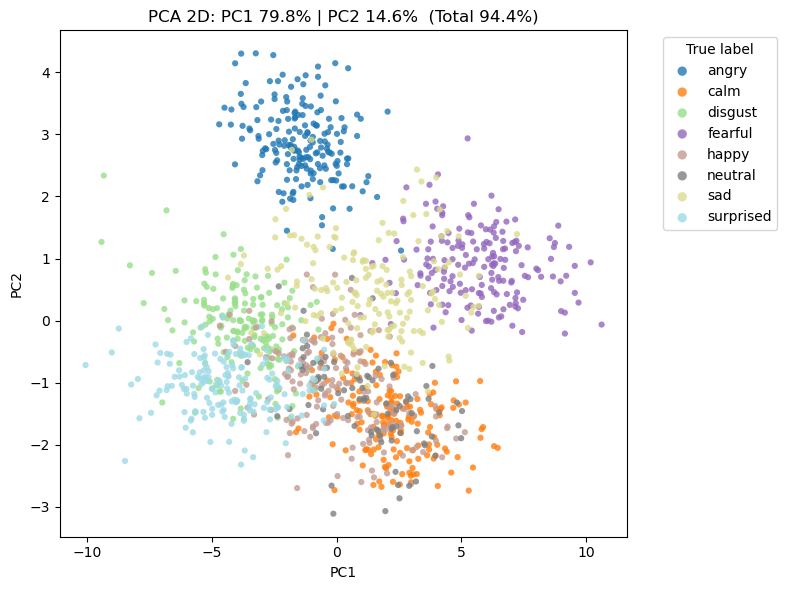

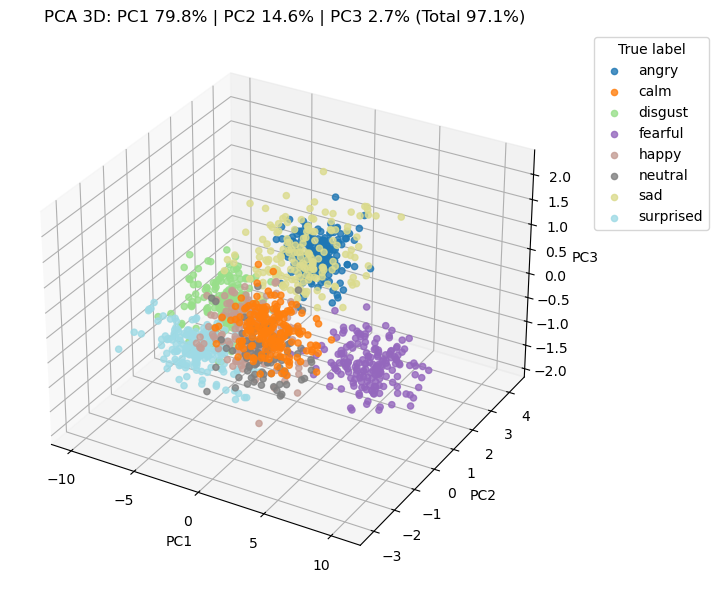

In [32]:
# Plot the PCA results (2D and 3D)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

labels = np.unique(y)

# Get the continuous colormap
cmap = mpl.colormaps.get_cmap("tab20")

# Sample exactly len(labels) colors
colors = cmap(np.linspace(0, 1, len(labels)))

# 2D scatter
plt.figure(figsize=(8, 6))
for i, lbl in enumerate(labels):
    
    lbl_idxs = (y == lbl)
    plt.scatter(
        X_pca2[lbl_idxs, 0], X_pca2[lbl_idxs, 1],
        s=20, alpha=0.8, color=colors[i], label=f"{lbl}", edgecolors="none"
    )
    
title2 = f"PCA 2D: PC1 {evr2[0]*100:.1f}% | PC2 {evr2[1]*100:.1f}%  (Total {evr2.sum()*100:.1f}%)"
plt.title(title2)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="True label", markerscale=1.5, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 3D scatter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
for i, lbl in enumerate(labels):
    idx = (y == lbl)
    ax.scatter(
        X_pca3[idx, 0], X_pca3[idx, 1], X_pca3[idx, 2],
        s=20, alpha=0.8, color=colors[i], label=f"{lbl}"
    )
title3 = (
    f"PCA 3D: PC1 {evr3[0]*100:.1f}% | PC2 {evr3[1]*100:.1f}% | PC3 {evr3[2]*100:.1f}% "
    f"(Total {evr3.sum()*100:.1f}%)"
)
ax.set_title(title3)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend(title="True label", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## labels distribution accross clusters + Centroids

In [34]:
from tcav_demo import LABEL_EMOTION_MAPPING, CONCEPT_UNIQUE_NAMES

def get_label_distribution_fitted(X, y, clustering_model, random_state=42, print_results=False):
    
    cluster_labels = clustering_model.predict(X)

    # Create a DataFrame to hold the cluster labels and true labels
    df = pd.DataFrame({'cluster': cluster_labels, 'true_label': y})

    # Get the distribution of clusters per true label
    label_distribution = df.groupby('true_label')['cluster'].value_counts(normalize=True).unstack(fill_value=0)

    #// # modify true_label to be the actual label names instead of numbers using LABEL_EMOTION_MAPPING
    
    #// label_distribution.index = label_distribution.index.map(LABEL_EMOTION_MAPPING)
    
    # add cluster suffix to each column name
    label_distribution.columns = [f"{col} clus" for col in label_distribution.columns]
    
    # Create DataFrame for centroids
    centroids_df = pd.DataFrame(
        clustering_model.cluster_centers_,
        index=[f"cluster_{i}" for i in range(clustering_model.cluster_centers_.shape[0])],
        columns=[f"{concept}" for concept in CONCEPT_UNIQUE_NAMES]
    )

    if print_results:
        print("Cluster distribution across labels:")
        print(label_distribution)
        print("\nCluster centroids:")
        print(centroids_df)

    return label_distribution, centroids_df

def get_label_distribution_unfitted(X, y, clustering_model, random_state=42, print_results=False):
    clustering_model.fit(X)
    return get_label_distribution_fitted(X, y, clustering_model, random_state, print_results)

#? Example usage:
# lbl_dist, cent_df = get_label_distribution_unfitted(X, y, KMeans(n_clusters=4, random_state=42), print_results=False)
# display(lbl_dist)
# display(cent_df)

In [35]:
from pprint import pprint
from sklearn.preprocessing import normalize

X = vector_df_glob.drop(columns=["path", "true_label"], inplace=False).to_numpy()
y = vector_df_glob["true_label"].to_numpy()

# normalize X
X = normalize(X, norm='l2', axis=1)        # put points on the unit sphere

lbl_dist, cent_df = get_label_distribution_unfitted(X, y, KMeans(n_clusters=5, random_state=42), print_results=False)
display(lbl_dist)
display(cent_df)

c:\Users\noams\anaconda3\envs\tf-TTS\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


,0 clus,1 clus,2 clus,3 clus,4 clus
true_label,,,,,
angry,0.000000,0.000000,0.967914,0.032086,0.000000
calm,0.890710,0.076503,0.000000,0.021858,0.010929
disgust,0.000000,0.988889,0.011111,0.000000,0.000000
fearful,0.000000,0.000000,0.000000,1.000000,0.000000
happy,0.482955,0.437500,0.022727,0.051136,0.005682
neutral,0.630952,0.273810,0.000000,0.083333,0.011905
sad,0.046784,0.081871,0.163743,0.081871,0.625731
surprised,0.005650,0.994350,0.000000,0.000000,0.000000


,long-constant-thick,long-dropping-flat-thick,long-dropping-steep-thick,long-dropping-steep-thin,long-rising-flat-thick,long-rising-steep-thick,long-rising-steep-thin,short-constant-thick,short-dropping-steep-thick,short-dropping-steep-thin,short-rising-steep-thick,short-rising-steep-thin
cluster_0,-0.139392,-0.563110,-0.103166,-0.355270,0.030527,-0.324213,-0.091419,-0.101604,-0.074843,-0.312312,-0.154584,0.154304
cluster_1,0.341175,0.195741,0.215620,0.290072,0.275252,0.282082,0.310740,0.156926,0.137571,0.097805,0.373896,0.228392
cluster_2,0.058294,0.475349,-0.141394,0.362995,-0.271103,0.345680,-0.199832,0.267046,-0.056911,0.312908,-0.028379,-0.188258
cluster_3,-0.238215,-0.259830,-0.274062,-0.293770,-0.178973,-0.264840,-0.366776,-0.206118,-0.228465,-0.166820,-0.407497,-0.322532
cluster_4,-0.461455,-0.175725,-0.200073,-0.239192,-0.406970,-0.196910,-0.307743,0.144402,-0.057126,-0.088240,-0.286803,0.010450


## Create centroids per label

In [36]:
# for each label, compute its centroid all in a df
centroids_per_label = {}
for label in np.unique(y):
    label_idxs = np.where(y == label)[0]
    if len(label_idxs) > 0:
        centroids_per_label[label] = X[label_idxs].mean(axis=0)

centroids_df = pd.DataFrame(centroids_per_label).T
# centroids_df.index = centroids_df.index.map(LABEL_EMOTION_MAPPING)
# for each column, set the name to be the concept name
centroids_df.columns = [f"{concept}" for concept in CONCEPT_UNIQUE_NAMES]
centroids_df

,long-constant-thick,long-dropping-flat-thick,long-dropping-steep-thick,long-dropping-steep-thin,long-rising-flat-thick,long-rising-steep-thick,long-rising-steep-thin,short-constant-thick,short-dropping-steep-thick,short-dropping-steep-thin,short-rising-steep-thick,short-rising-steep-thin
angry,0.077323,0.479915,-0.159051,0.368064,-0.266665,0.337379,-0.229648,0.233307,-0.084627,0.311555,-0.058998,-0.239741
calm,-0.077173,-0.584849,-0.075822,-0.292773,-0.035622,-0.312003,-0.139090,-0.030128,-0.065500,-0.245617,-0.156545,0.211077
disgust,0.330434,0.301258,0.163259,0.398583,0.209885,0.359224,0.283938,0.235963,0.147099,0.129169,0.359154,0.204970
fearful,-0.224489,-0.260029,-0.270520,-0.297037,-0.173511,-0.274373,-0.371173,-0.221569,-0.234073,-0.163143,-0.431306,-0.351655
happy,0.005033,-0.233505,-0.023842,-0.117157,0.175390,-0.033252,0.174738,-0.034086,0.030331,-0.156227,0.121920,0.190578
neutral,-0.071350,-0.286953,0.029415,-0.260156,0.200294,-0.237941,-0.032876,-0.190651,-0.061927,-0.295499,0.000215,0.071796
sad,-0.351969,-0.069966,-0.152712,-0.132466,-0.351975,-0.081296,-0.223295,0.199979,-0.020484,-0.023705,-0.191528,0.038050
surprised,0.429837,0.182718,0.281493,0.271908,0.348330,0.271716,0.327098,0.108973,0.119095,0.114657,0.387340,0.192425


In [37]:
import numpy as np
import pandas as pd

class CentroidClassifier:
    """
    Classify by nearest centroid computed beforehand.
    centroids_df: DataFrame with index=emotion names, columns=concepts, values=centroid coords.
    metric: 'euclidean' | 'cosine' | 'manhattan'
    temperature: softmax temperature for predict_proba (smaller = sharper).
    """
    def __init__(self, centroids_df: pd.DataFrame, metric: str = "cosine", temperature: float = 1.0):
        self.metric = metric
        self.tau = float(temperature)
        self.labels_ = centroids_df.index.to_numpy()
        self.columns_ = centroids_df.columns
        self.cluster_centers_ = centroids_df.to_numpy(dtype=float)  # (n_centroids, d)

    def _to_array(self, X):
        # Accepts np.ndarray or DataFrame; if DF, align columns to centroids
        if isinstance(X, pd.DataFrame):
            missing = set(self.columns_) - set(X.columns)
            if missing:
                raise ValueError(f"X is missing columns: {sorted(missing)}")
            X = X.loc[:, self.columns_].to_numpy(dtype=float)
        else:
            X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X[None, :]
        return X

    def _distances(self, X):
        X = self._to_array(X)  # (n, d)
        if self.metric == "euclidean":
            d = np.sqrt(((X[:, None, :] - self.cluster_centers_[None, :, :]) ** 2).sum(axis=2))
        elif self.metric == "manhattan":
            d = np.abs(X[:, None, :] - self.cluster_centers_[None, :, :]).sum(axis=2)
        elif self.metric == "cosine":
            eps = 1e-12
            Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)
            Cn = self.cluster_centers_ / (np.linalg.norm(self.cluster_centers_, axis=1, keepdims=True) + eps)
            d = 1.0 - Xn @ Cn.T
        else:
            raise ValueError(f"Unsupported metric: {self.metric}")
        return d  # shape (n_samples, n_centroids)

    def predict(self, X):
        d = self._distances(X)
        return self.labels_[d.argmin(axis=1)]

    def decision_function(self, X):
        # Higher is better (negative distance)
        return -self._distances(X)

    def predict_proba(self, X):
        # Softmax over negative distances (temperature = tau)
        s = self.decision_function(X) / self.tau
        s -= s.max(axis=1, keepdims=True)
        e = np.exp(s)
        return e / e.sum(axis=1, keepdims=True)  # shape (n_samples, n_centroids)

In [40]:
# Build classifier from your centroids
clf = CentroidClassifier(centroids_df, metric="cosine", temperature=0.5)

# Classify new samples in the same concept space (numpy array or DataFrame with same columns)
y_pred_names = clf.predict(X)              # array of emotion names (centroid labels)
probas = clf.predict_proba(X)              # soft assignment to each emotion (columns=centroids_df.index)

#// # If you need numeric IDs back (inverse of LABEL_EMOTION_MAPPING):
#// name_to_id = {v: k for k, v in LABEL_EMOTION_MAPPING.items()}
#// y_pred_ids = np.vectorize(name_to_id.get)(y_pred_names)

In [41]:
# evaluate clustering on centroids_df using
# ---- STEP 4: Evaluation (since you have ground truth labels) ----
print("ARI:", adjusted_rand_score(y, y_pred_names))
print("Silhouette:", silhouette_score(X, y_pred_names))

# Intra-cluster and inter-cluster scores
print(intra_inter_scores(X, y_pred_names, metric="euclidean"))

ARI: 0.5427717921701636
Silhouette: 0.2916410031548553
{'intra_mean': 0.5605109651195883, 'inter_mean': 1.4014366824521625, 'separation': 2.500284150825056}


In [42]:
from pprint import pprint
from sklearn.preprocessing import normalize

X = vector_df_glob.drop(columns=["path", "true_label"], inplace=False).to_numpy()
y = vector_df_glob["true_label"].to_numpy()

# normalize X
X = normalize(X, norm='l2', axis=1)        # put points on the unit sphere

lbl_dist, cent_df = get_label_distribution_fitted(X, y, clf, print_results=False)
display(lbl_dist)
display(cent_df)

,angry clus,calm clus,disgust clus,fearful clus,happy clus,neutral clus,sad clus,surprised clus
true_label,,,,,,,,
angry,0.973262,0.000000,0.005348,0.021390,0.000000,0.000000,0.000000,0.000000
calm,0.000000,0.836066,0.016393,0.038251,0.049180,0.005464,0.005464,0.049180
disgust,0.005556,0.000000,0.888889,0.000000,0.005556,0.000000,0.000000,0.100000
fearful,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
happy,0.022727,0.272727,0.102273,0.056818,0.187500,0.113636,0.005682,0.238636
neutral,0.000000,0.202381,0.035714,0.095238,0.107143,0.380952,0.011905,0.166667
sad,0.134503,0.064327,0.111111,0.192982,0.000000,0.000000,0.497076,0.000000
surprised,0.000000,0.000000,0.146893,0.000000,0.011299,0.005650,0.000000,0.836158


,long-constant-thick,long-dropping-flat-thick,long-dropping-steep-thick,long-dropping-steep-thin,long-rising-flat-thick,long-rising-steep-thick,long-rising-steep-thin,short-constant-thick,short-dropping-steep-thick,short-dropping-steep-thin,short-rising-steep-thick,short-rising-steep-thin
cluster_0,0.077323,0.479915,-0.159051,0.368064,-0.266665,0.337379,-0.229648,0.233307,-0.084627,0.311555,-0.058998,-0.239741
cluster_1,-0.077173,-0.584849,-0.075822,-0.292773,-0.035622,-0.312003,-0.139090,-0.030128,-0.065500,-0.245617,-0.156545,0.211077
cluster_2,0.330434,0.301258,0.163259,0.398583,0.209885,0.359224,0.283938,0.235963,0.147099,0.129169,0.359154,0.204970
cluster_3,-0.224489,-0.260029,-0.270520,-0.297037,-0.173511,-0.274373,-0.371173,-0.221569,-0.234073,-0.163143,-0.431306,-0.351655
cluster_4,0.005033,-0.233505,-0.023842,-0.117157,0.175390,-0.033252,0.174738,-0.034086,0.030331,-0.156227,0.121920,0.190578
cluster_5,-0.071350,-0.286953,0.029415,-0.260156,0.200294,-0.237941,-0.032876,-0.190651,-0.061927,-0.295499,0.000215,0.071796
cluster_6,-0.351969,-0.069966,-0.152712,-0.132466,-0.351975,-0.081296,-0.223295,0.199979,-0.020484,-0.023705,-0.191528,0.038050
cluster_7,0.429837,0.182718,0.281493,0.271908,0.348330,0.271716,0.327098,0.108973,0.119095,0.114657,0.387340,0.192425
